In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, log_loss, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import optuna

In [14]:
raw_train = pd.read_csv('train.csv')
raw_test = pd.read_csv('test.csv')

df = raw_train.copy()
test_df = raw_test.copy()

In [15]:
print(df.head())
print(df.shape)
print(df.dtypes)
print(df['Gender'].unique())
print(df['City_Type'].unique())
print(df['Current_Car_Type'].unique())
print(df['Home_Charging_Possible'].unique())
print(df['Subsidy_Available'].unique())
print(df['Range_Anxiety_Level'].unique())
print(df['Will_Buy_EV'].value_counts())

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66            92887.0              23.4                     2   
1   1   38            30000.0               5.0                     1   
2   2   26            94389.0              36.8                     1   
3   3   66            73580.0              23.7                     2   
4   4   54            57898.0              50.8                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                          1.0    Male  Suburban            Sedan   
1                          4.0    Male     R

data is mostly unbalanced with 83% of people not buying an EV

In [16]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64
0
                  id            Age  Annual_Income_USD  Daily_Commute_km  \
count  668665.000000  668665.000000      668665.000000     668665.000000   
mean   334332.000000      47.039171       84769.266989         32.158298   
std    193027.103211      12.875448       28648.029042         18.730474   
min         0.000000      25.000000       30000.000000          5.000000   
25%    167166.000000      36.000000       67376.000000         17.200000   
50%    334332.000000      47.00000

No nulls, no duplicates

C:\Users\lina ahmed\AppData\Local\Temp\ipykernel_23068\2581236749.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set2', ax=axes[i])
C:\Users\lina ahmed\AppData\Local\Temp\ipykernel_23068\2581236749.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set2', ax=axes[i])
C:\Users\lina ahmed\AppData\Local\Temp\ipykernel_23068\2581236749.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='Set2', ax=axes[i])
C:\Users\lina ahmed\AppData\Local\Temp\i

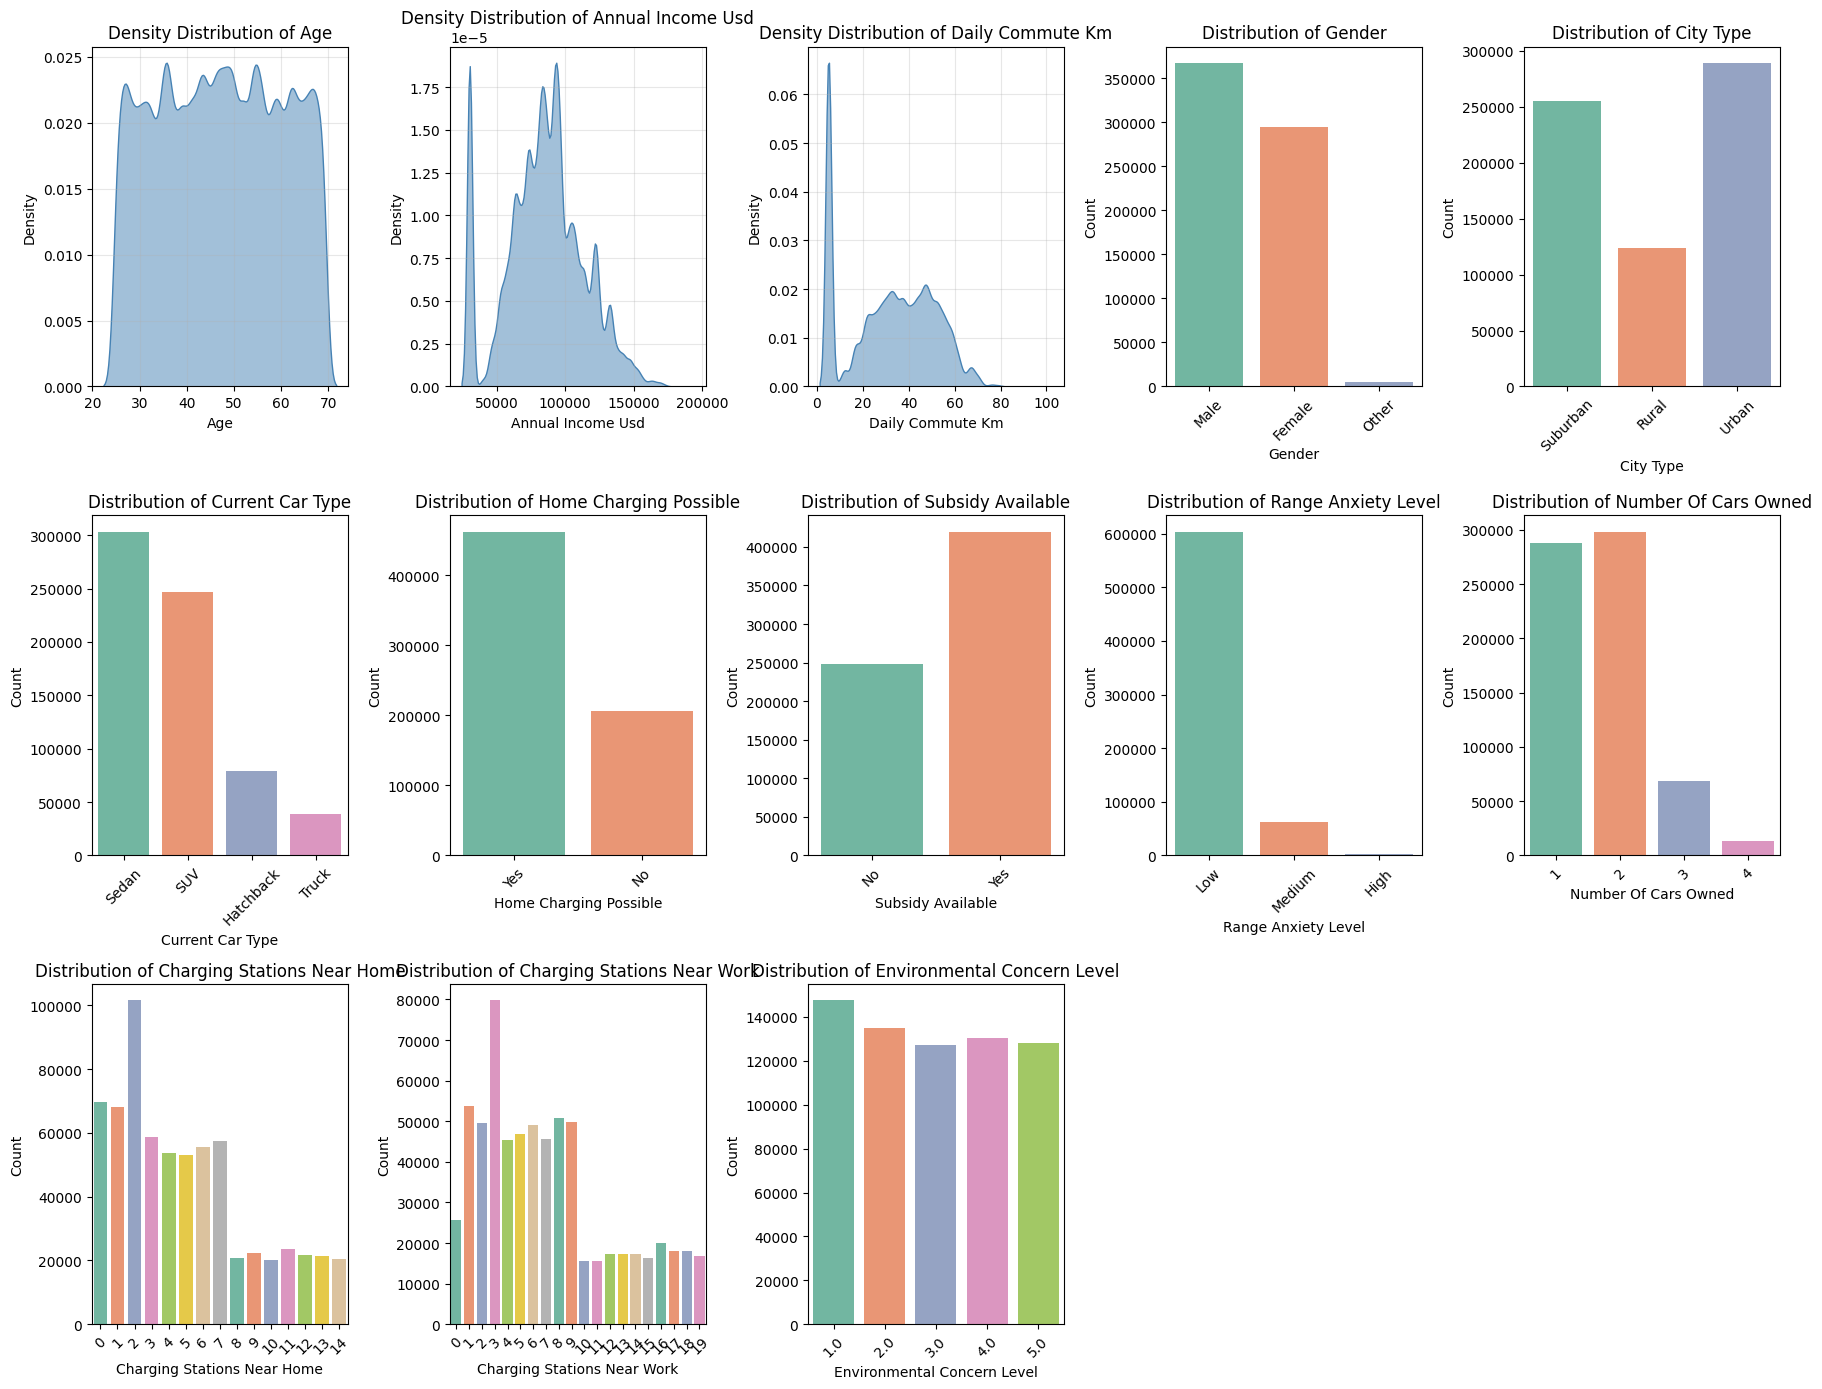

In [17]:
numeric_features = ['Age','Annual_Income_USD', 'Daily_Commute_km']
categorical_features = ['Gender','City_Type','Current_Car_Type','Home_Charging_Possible','Subsidy_Available','Range_Anxiety_Level']
int_features = ['Number_of_Cars_Owned','Charging_Stations_Near_Home','Charging_Stations_Near_Work','Environmental_Concern_Level']

fig, axes = plt.subplots(3, 5, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.kdeplot(df[feature], fill=True, color='steelblue', alpha=0.5, ax=axes[i])
    axes[i].set_title(f'Density Distribution of {feature.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].grid(alpha=0.3)

for i, feature in enumerate(categorical_features, start=len(numeric_features)):
    sns.countplot(data=df, x=feature, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for i, feature in enumerate(int_features, start=(len(numeric_features) + len(categorical_features))):
    sns.countplot(data=df, x=feature, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(numeric_features) + len(categorical_features) + len(int_features), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    df.drop(columns=['id','Will_Buy_EV']),
    df['Will_Buy_EV'],
    test_size=0.2,
    random_state=42,
    stratify= df['Will_Buy_EV'] # seeing as data is heavily imbalanced, needed so all classes are present
)

x_val_final, x_calib_raw, y_val_final, y_calib = train_test_split(
    x_val_raw, y_val,
    test_size=0.5,
    random_state=42,
    stratify=y_val
)

y_train     = y_train.map({"No": 0, "Yes": 1})
y_val = y_val_final.map({"No": 0, "Yes": 1})
y_calib     = y_calib.map({"No": 0, "Yes": 1})

In [22]:
# encoding
all_numeric_features = ['Age','Annual_Income_USD', 'Daily_Commute_km','Number_of_Cars_Owned',
                        'Charging_Stations_Near_Home','Charging_Stations_Near_Work','Environmental_Concern_Level']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, all_numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

def cleaning(df, is_val = False, preprocessor = preprocessor):
    if is_val:
        df_preprocessed = preprocessor.transform(df)
    else:
        df_preprocessed = preprocessor.fit_transform(df)

    return df_preprocessed

x_train = cleaning(x_train_raw)
x_val = cleaning(x_val_final, is_val=True)
x_calib = cleaning(x_calib_raw, is_val=True)

Since the data size is pretty big and there is data imbalance, ill train a lightGBM model for its speed and good handling of imbalanced data

In [23]:
# lightgbm
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos


train_dataset = lgb.Dataset(x_train, label=y_train)
validation_dataset = lgb.Dataset(x_val, label=y_val, reference=train_dataset)

params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "scale_pos_weight": scale_pos_weight,
    "verbosity": -1,
    "seed": 42,
}

lgb_model = lgb.train(
    params,
    train_dataset,
    num_boost_round=2000,
    valid_sets=[train_dataset, validation_dataset],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[28]	train's binary_logloss: 0.300838	train's auc: 0.940846	train's average_precision: 0.751996	val's binary_logloss: 0.300981	val's auc: 0.940178	val's average_precision: 0.75277


In [24]:
# hyperparameter optimization

def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "seed": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True), # log scale
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": -1,
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
    }

    train_data = lgb.Dataset(x_train, label=y_train)
    val_data = lgb.Dataset(x_val, label=y_val, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=2000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )

    y_pred = model.predict(x_val, num_iteration=model.best_iteration)
    return roc_auc_score(y_val, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(study.best_params)
print(study.best_value)

[I 2026-09-13 03:14:49,136] A new study created in memory with name: no-name-6f8b9f62-4a59-4f60-9f78-49052e26e2f7


Training until validation scores don't improve for 50 rounds


[I 2026-09-13 03:14:49,892] Trial 0 finished with value: 0.9395663445095173 and parameters: {'learning_rate': 0.01289536545282769, 'num_leaves': 30, 'min_child_samples': 108, 'feature_fraction': 0.6629002281995755, 'bagging_fraction': 0.777816768027938, 'bagging_freq': 1, 'lambda_l1': 0.00014529912392615666, 'lambda_l2': 3.533866529558745e-05, 'scale_pos_weight': 7.012724458594661}. Best is trial 0 with value: 0.9395663445095173.


Early stopping, best iteration is:
[8]	valid_0's auc: 0.939566
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[266]	valid_0's auc: 0.941611


[I 2026-09-13 03:14:55,921] Trial 1 finished with value: 0.9416114464918327 and parameters: {'learning_rate': 0.042296886804477275, 'num_leaves': 218, 'min_child_samples': 41, 'feature_fraction': 0.6406252130880523, 'bagging_fraction': 0.7569301707289648, 'bagging_freq': 1, 'lambda_l1': 0.14330913741213905, 'lambda_l2': 8.281221126819702e-08, 'scale_pos_weight': 4.597489117772189}. Best is trial 1 with value: 0.9416114464918327.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[363]	valid_0's auc: 0.941846


[I 2026-09-13 03:38:07,100] Trial 98 finished with value: 0.941845559607532 and parameters: {'learning_rate': 0.06795629847251838, 'num_leaves': 32, 'min_child_samples': 181, 'feature_fraction': 0.5338759511660851, 'bagging_fraction': 0.9842663005010697, 'bagging_freq': 9, 'lambda_l1': 5.03693536317579e-08, 'lambda_l2': 1.0248446022305412e-08, 'scale_pos_weight': 1.6379217249918705}. Best is trial 54 with value: 0.9420382838921564.


Training until validation scores don't improve for 50 rounds


[I 2026-09-13 03:38:28,655] Trial 99 finished with value: 0.9419239345326803 and parameters: {'learning_rate': 0.08003184695121071, 'num_leaves': 33, 'min_child_samples': 180, 'feature_fraction': 0.5214715075106849, 'bagging_fraction': 0.9415485157144464, 'bagging_freq': 9, 'lambda_l1': 7.482412548564503e-08, 'lambda_l2': 4.3659794644838635e-08, 'scale_pos_weight': 1.8889104638344838}. Best is trial 54 with value: 0.9420382838921564.


Early stopping, best iteration is:
[407]	valid_0's auc: 0.941924
{'learning_rate': 0.07453164139068869, 'num_leaves': 15, 'min_child_samples': 168, 'feature_fraction': 0.5245362793664187, 'bagging_fraction': 0.9466035360694156, 'bagging_freq': 9, 'lambda_l1': 1.2293452659443272e-06, 'lambda_l2': 1.0259708287752999e-08, 'scale_pos_weight': 1.3705038377007073}
0.9420382838921564


{'learning_rate': 0.07453164139068869, 'num_leaves': 15, 'min_child_samples': 168, 'feature_fraction': 0.5245362793664187, 'bagging_fraction': 0.9466035360694156, 'bagging_freq': 9, 'lambda_l1': 1.2293452659443272e-06, 'lambda_l2': 1.0259708287752999e-08, 'scale_pos_weight': 1.3705038377007073}
best auc: 0.9420382838921564

In [25]:
best_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "seed": 42,
    'learning_rate': 0.074532,
    'num_leaves': 15,
    'min_child_samples': 168,
    'feature_fraction': 0.524536,
    'bagging_fraction': 0.946604,
    'bagging_freq': 9,
    'lambda_l1': 0.000001229,
    'lambda_l2': 0.0000000103,
    'scale_pos_weight': 1.370504
}

model = lgb.train(
    best_params,
    train_dataset,
    num_boost_round=2000,
    valid_sets=[validation_dataset],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[676]	valid_0's binary_logloss: 0.229653


In [26]:
# calibration
sk_model = lgb.LGBMClassifier(
    **{k: v for k, v in best_params.items() if k != "metric"},
    n_estimators=model.best_iteration
)
sk_model.fit(x_train, y_train)

# 2. Freeze it, then calibrate — this replaces cv="prefit"
calibrated_model = CalibratedClassifierCV(FrozenEstimator(sk_model), method="isotonic")
calibrated_model.fit(x_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...verbosity=-1))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.074532
,n_estimators,676
,subsample_for_bin,200000


In [32]:
final_val = calibrated_model.predict_proba(x_val)[:, 1]
log_loss_stacking = log_loss(y_val, final_val)

print(f"LGB log loss: {log_loss_stacking:.4f}")
print(f"LGB ROC-AUC: {roc_auc_score(y_val, final_val):.4f}")

LGB log loss: 0.2267
LGB ROC-AUC: 0.9418


In [28]:
test_ids = test_df['id'].copy()
x_test = cleaning(test_df, is_val=True)

test_proba = calibrated_model.predict_proba(x_test)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'Will_Buy_EV': test_proba
})
submission.to_csv('submission_2.csv', index=False)